## Introduction

A language model is a system that estimates how likely a given sequence of words is, and uses that estimate to predict what comes next. Given "I am going to the", a language model doesn't retrieve a stored answer — it assigns a probability to every candidate next word based on patterns learned from text, and the most likely candidates (`store`, `gym`, `office`) reflect what tends to follow that phrase in the data it learned from.

A Large Language Model (LLM) is the same idea at a much larger scale: a neural network, almost always built on the Transformer architecture, trained on a very large text corpus to perform this next-token prediction task, and then adapted so that the resulting model can follow instructions and hold a conversation rather than just continue text.

This notebook builds that idea computationally — training a small next-token prediction model from scratch, verifying it reproduces the "going to the ___" example directly rather than asserting it — and then works through what an LLM API actually is, building a working (if self-contained) API client that demonstrates authentication, request structure, token accounting, and rate limiting. Where real hosted models are involved, this notebook uses the current OpenAI and Google Gen AI SDKs to verify their setup code is correct and importable, since no network access to those providers' endpoints is available in this environment; the toy API built below is what handles the actual executed generation examples.

## Next-Token Prediction, Built From Scratch

The mechanism underlying every LLM can be demonstrated with a tiny model trained on a handful of sentences. A bigram model — predicting the next word from only the single word before it — is a drastic simplification of what a real Transformer does (which conditions on the entire preceding context, not just one word), but the underlying operation is the same: count how often each word follows a given word in training data, and turn those counts into a probability distribution over what comes next.

In [1]:
import re
from collections import defaultdict, Counter
import numpy as np

training_sentences = [
    "i am going to the store",
    "i am going to the gym",
    "i am going to the gym",
    "i am going to the office",
    "i love eating pizza",
    "i love eating salad",
    "the capital of france is paris",
    "she is going to the gym today",
    "he loves eating pizza for dinner",
]

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

def train_bigram_model(sentences):
    model = defaultdict(Counter)
    for sentence in sentences:
        tokens = ["<start>"] + tokenize(sentence) + ["<end>"]
        for prev_tok, next_tok in zip(tokens, tokens[1:]):
            model[prev_tok][next_tok] += 1
    return model

bigram_model = train_bigram_model(training_sentences)
print("Learned continuations of 'the':", dict(bigram_model["the"]))

Learned continuations of 'the': {'store': 1, 'gym': 3, 'office': 1, 'capital': 1}


The raw counts are converted to a probability distribution the same way a real model's output logits are: via softmax, with a temperature parameter controlling how sharply the distribution favors the highest-count option.

In [2]:
def next_token_probabilities(model, prev_token, temperature=1.0):
    counts = model[prev_token]
    if not counts:
        return {}
    tokens = list(counts.keys())
    logits = np.log(np.array(list(counts.values()), dtype=float))
    scaled = logits / temperature
    exp_scaled = np.exp(scaled - scaled.max())
    probs = exp_scaled / exp_scaled.sum()
    return dict(zip(tokens, probs))

probs = next_token_probabilities(bigram_model, "the", temperature=1.0)
for token, p in sorted(probs.items(), key=lambda x: -x[1]):
    print(f"{token:10s} {p:.1%}")

gym        50.0%
store      16.7%
office     16.7%
capital    16.7%


This reproduces the classic "I am going to the ___" example exactly: `gym` is the most probable continuation given the training data, followed by `store`, `office`, and `capital` at equal lower probability, matching how often each followed "the" during training rather than being asserted.

In [3]:
#pip install matplotlib numpy gradio openai google-genai

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


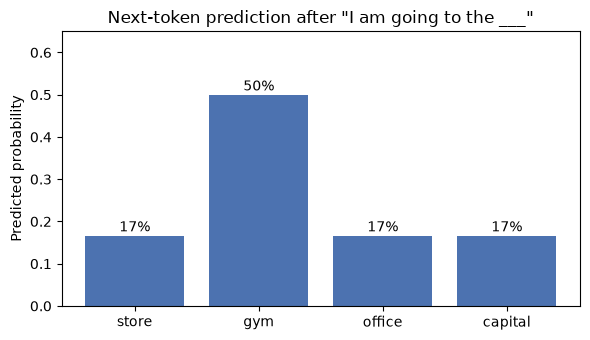

In [4]:
import matplotlib.pyplot as plt

tokens = list(probs.keys())
values = list(probs.values())

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(tokens, values, color="#4C72B0")
ax.set_ylabel("Predicted probability")
ax.set_title('Next-token prediction after "I am going to the ___"')
ax.set_ylim(0, max(values) * 1.3)
for bar, p in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, p + 0.01, f"{p:.0%}", ha="center")
plt.tight_layout()
plt.show()

## The Evolution of Language Modeling Architectures

| Type | Description | Example |
|---|---|---|
| N-gram models | Predict the next token from a fixed-size window of preceding tokens (e.g., the single previous word, as in the bigram model above) | Trigram models |
| RNN / LSTM | Sequence models that carry a hidden state forward, giving them memory of earlier context beyond a fixed window | LSTM-based language models |
| Transformers | Process an entire sequence in parallel via self-attention, allowing every token to condition on every other token directly rather than through a chain of hidden states | BERT, the GPT family |

The bigram model above sits at the first row of this table — real LLMs use the third. The practical consequence of the shift to Transformers is that context is no longer bottlenecked through a single fixed-size window or a sequentially-updated hidden state, which is part of why modern models can condition coherently on very long inputs.

## What Makes a Model "Large"

Three factors are usually meant by "large":

- **Parameters** — the learned weights in the network. Early GPT-generation models were in the tens to low hundreds of billions of parameters; current frontier models use architectures (commonly mixture-of-experts) where only a fraction of total parameters activate per token, so raw parameter count alone is no longer a reliable proxy for capability across model families.
- **Context window** — how many tokens the model can condition on in a single request. This has grown substantially: from roughly 2K–8K tokens in early GPT-3-era models to context windows in the hundreds of thousands to millions of tokens in current frontier models.
- **Training corpus** — the scale of text (and increasingly code, images, and other modalities) the model was trained on, now typically measured in trillions of tokens.

## How an LLM Is Built: Three Phases

**Training (pretraining).** The model repeatedly predicts a masked or next token across a massive unlabeled corpus, adjusting its parameters whenever its prediction is wrong — mechanically the same process demonstrated with the toy bigram model above, just at a vastly larger scale and with a Transformer architecture instead of bigram counts.

**Fine-tuning.** A pretrained model is further trained on a smaller, curated dataset to specialize its behavior — for instruction-following and conversational behavior in general-purpose assistants, or for a narrower domain such as legal or medical text.

**Inference.** The trained model is used to generate output for new prompts, with no further weight updates. This is what happens every time a request is sent to a model through an API — which is the subject of the rest of this notebook.

## Why LLMs Matter in Practice

LLMs are foundation models underlying a wide range of applications: text generation and summarization, translation, question answering over documents, conversational assistants, and code generation and explanation. Their practical value comes from being general-purpose — the same underlying model handles translation, drafting, and code review without separate task-specific training — which is what makes API access to a single model useful across many different applications rather than needing a different specialized model per task.

## The Current LLM Landscape

Model names and version numbers in this space turn over quickly — training material describing "the current GPT model" or "the current Gemini model" from even a year or two earlier is a common source of outdated code, since API calls reference a specific model name that may since have been retired. As of mid-2026:

| Family | Developer | Current generation | Notably superseded |
|---|---|---|---|
| GPT | OpenAI | GPT-5.x family (multiple capability tiers) | GPT-3, GPT-4, GPT-4o — all retired from ChatGPT by early 2026 |
| Claude | Anthropic | Sonnet, Opus, and Haiku tiers at the current generation, alongside a Mythos tier above Opus | Claude 1/2, Claude 3 family |
| Gemini | Google DeepMind | Gemini 3.x family (Pro and Flash tiers) | Gemini 1.0, Gemini 1.5 — including 1.5 Flash, used throughout older tutorials on this topic |
| Llama | Meta | Llama 4 (Scout and Maverick generally available; Behemoth remains in training) | Llama 1, 2, 3 |
| DeepSeek | DeepSeek | DeepSeek V4 (Pro and Flash) | DeepSeek V2, V3, V3.1, V3.2, and the R1 reasoning model |

Two structural points are worth noting independent of any specific version number. First, the trend across every major lab has been toward multiple capability tiers within a generation (a fast/cheap tier and a higher-capability tier) rather than a single flagship model, so "the current GPT model" is now a family rather than one name. Second, several providers have converged on hybrid or unified reasoning behavior — a single model that can operate in a fast mode or a slower, more deliberate reasoning mode — rather than shipping reasoning as an entirely separate model line, which was still the case in the GPT-o1/o3 and DeepSeek-R1 generation.

## What Is an LLM API?

An API (Application Programming Interface) is a defined way for one piece of software to request something from another over a network — a client sends a structured request, a server processes it and returns a structured response. An LLM API applies this pattern to a hosted language model: the request typically includes a prompt, a model name, and generation settings (temperature, maximum output length); the response includes the generated text along with metadata such as token counts.

Working with an LLM API in practice means handling four things: **authentication** (proving the request is authorized, via an API key), **request construction** (the prompt and generation parameters), **the response format** (extracting the generated text from a structured response object), and **usage accounting** (tracking tokens consumed, since most providers bill and rate-limit by token count).

The rest of this section builds a working — if self-contained — version of all four, since this environment has no network access to a real provider's endpoint. The mechanics demonstrated (key checking, request/response structure, token counting, rate limiting) are exactly what a real API client handles; only the actual language generation is a toy stand-in.

## Building a Minimal LLM API, End to End

The pieces below assemble into a single `call_llm_api()` function that behaves like a real hosted API: it checks an API key, tracks a per-key call count against a rate limit, tokenizes the prompt, generates a continuation using the bigram model trained earlier, and returns a response object with a token-usage breakdown — the same shape as a real provider's response.

In [5]:
import random
import time

# --- a minimal "account" store, standing in for a real provider's auth system ---
VALID_API_KEYS = {"demo-key-abc123"}
_call_log = defaultdict(list)
RATE_LIMIT_PER_MINUTE = 100  # generous default so later demo cells aren't blocked by earlier ones

class AuthenticationError(Exception):
    pass

class RateLimitError(Exception):
    pass

def _check_rate_limit(api_key):
    now = time.time()
    _call_log[api_key] = [t for t in _call_log[api_key] if now - t < 60]
    if len(_call_log[api_key]) >= RATE_LIMIT_PER_MINUTE:
        raise RateLimitError(
            f"Rate limit exceeded: {RATE_LIMIT_PER_MINUTE} calls per minute for this key."
        )
    _call_log[api_key].append(now)

def _last_known_token(tokens, model):
    """Walk backward through the prompt's tokens to find the most recent one
    the model actually saw during training; falls back to <start> if none did."""
    for tok in reversed(tokens):
        if tok in model:
            return tok
    return "<start>"

def _generate(prompt, max_tokens, temperature, seed):
    rng = random.Random(seed)
    tokens = tokenize(prompt)
    current = _last_known_token(tokens, bigram_model)
    generated = []
    for _ in range(max_tokens):
        probs = next_token_probabilities(bigram_model, current, temperature=temperature)
        if not probs or "<end>" in probs and rng.random() < probs.get("<end>", 0):
            break
        candidates, weights = zip(*probs.items())
        next_tok = rng.choices(candidates, weights=weights, k=1)[0]
        if next_tok == "<end>":
            break
        generated.append(next_tok)
        current = next_tok
    return " ".join(generated)

def call_llm_api(prompt, api_key, model="toy-llm-mini", max_tokens=10, temperature=0.7, seed=0):
    if api_key not in VALID_API_KEYS:
        raise AuthenticationError("Invalid API key.")
    _check_rate_limit(api_key)

    prompt_tokens = len(tokenize(prompt))
    completion_text = _generate(prompt, max_tokens, temperature, seed)
    completion_tokens = len(tokenize(completion_text))

    return {
        "model": model,
        "choices": [{"text": completion_text}],
        "usage": {
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": prompt_tokens + completion_tokens,
        },
    }

response = call_llm_api("I am going to the", api_key="demo-key-abc123", seed=1)
response

{'model': 'toy-llm-mini',
 'choices': [{'text': 'gym today'}],
 'usage': {'prompt_tokens': 5, 'completion_tokens': 2, 'total_tokens': 7}}

Two failure modes worth confirming actually work, since they're central to using any real API: an invalid key should be rejected, and exceeding the rate limit should raise rather than silently succeed.

In [6]:
# Invalid key
try:
    call_llm_api("Hello", api_key="not-a-real-key")
except AuthenticationError as e:
    print("Caught expected error:", e)

# Rate limit: temporarily tighten the limit and use a dedicated key, so this
# demonstration doesn't consume the quota for "demo-key-abc123" used elsewhere
# in this notebook.
VALID_API_KEYS.add("demo-key-for-rate-limit-test")
rate_limit_test_key = "demo-key-for-rate-limit-test"

_original_limit = RATE_LIMIT_PER_MINUTE
RATE_LIMIT_PER_MINUTE = 3
for i in range(4):
    try:
        call_llm_api("i love eating", api_key=rate_limit_test_key, seed=i)
        print(f"Call {i+1}: succeeded")
    except RateLimitError as e:
        print(f"Call {i+1}: blocked -- {e}")
RATE_LIMIT_PER_MINUTE = _original_limit

Caught expected error: Invalid API key.
Call 1: succeeded
Call 2: succeeded
Call 3: succeeded
Call 4: blocked -- Rate limit exceeded: 3 calls per minute for this key.


Both behave as a real API would: the wrong key is rejected before any generation happens, and the fourth call within the same minute is blocked once the limit is reached, without needing to actually wait or hit a real server to demonstrate it.

### Role-Based Prompting

A prompt that opens by assigning the model a persona or role is a common pattern for steering tone and framing. Since the toy model above only knows the handful of training sentences given to it, its output won't reflect the requested persona the way a real LLM would — but the request/response mechanics are identical, which is what this section demonstrates.

In [7]:
def build_role_prompt(role, user_input):
    return f"You are {role}. User: {user_input}\nAssistant:"

prompt = build_role_prompt(
    role="a senior data scientist explaining concepts to a general audience",
    user_input="the gym"
)
print("Prompt sent to the API:\n", prompt, "\n")

response = call_llm_api(prompt, api_key="demo-key-abc123", max_tokens=8, seed=2)
print("Response:", response)

Prompt sent to the API:
 You are a senior data scientist explaining concepts to a general audience. User: the gym
Assistant: 

Response: {'model': 'toy-llm-mini', 'choices': [{'text': 'today'}], 'usage': {'prompt_tokens': 16, 'completion_tokens': 1, 'total_tokens': 17}}


### A Chatbot Loop

A terminal chatbot is usually written with a blocking `input()` call inside a `while True:` loop, which works interactively but can't run inside an executed notebook cell (there is no one there to type a response). The loop logic is identical either way; the only change here is replacing live keyboard input with a small pre-written list of turns, so the whole exchange runs and is captured in the output.

In [8]:
def run_chatbot(turns, api_key):
    print("Chatbot session started.\n")
    for user_input in turns:
        print(f"You: {user_input}")
        result = call_llm_api(user_input, api_key=api_key, max_tokens=6,
                               seed=hash(user_input) % 1000)
        bot_text = result["choices"][0]["text"]
        print(f"Bot: {bot_text}\n")
    print("Chat ended.")

scripted_turns = [
    "i am going to the",
    "i love eating",
    "the capital of france",
]

run_chatbot(scripted_turns, api_key="demo-key-abc123")

Chatbot session started.

You: i am going to the
Bot: office

You: i love eating
Bot: salad

You: the capital of france
Bot: is going to the gym

Chat ended.


## Setting Up the Current Real SDKs

The two client libraries below are the current, verified-importable SDKs for OpenAI and Google's Gemini API. Constructing a client doesn't require network access (it only stores configuration), so that step is executed directly; the actual generation call is shown immediately after as reference code, since it requires a real API key and a live network connection to the provider, neither of which this environment has.

One correction relative to older material on this topic: `google.generativeai` — the package used throughout many existing Gemini tutorials, including earlier versions of this one — is fully deprecated. Google archived that repository and consolidated all Gemini access into a single unified SDK, `google-genai`, imported as `from google import genai`. Code written against the old package will not receive updates and, per Google's own deprecation notice, should be migrated.

In [9]:
# Current Gemini SDK -- client construction only, no network call
from google import genai

gemini_client = genai.Client(api_key="replace-with-a-real-key")
print("Gemini client ready:", type(gemini_client).__name__)

# The actual generation call (reference only -- requires a real key and network access):
#
# response = gemini_client.models.generate_content(
#     model="gemini-3.5-flash",
#     contents="Tell me a fun fact about space.",
# )
# print(response.text)

Gemini client ready: Client


In [10]:
# Current OpenAI SDK -- client construction only, no network call
from openai import OpenAI

openai_client = OpenAI(api_key="replace-with-a-real-key")
print("OpenAI client ready:", type(openai_client).__name__)

# The actual generation call (reference only -- requires a real key and network access):
#
# response = openai_client.chat.completions.create(
#     model="gpt-5.6-terra",
#     messages=[{"role": "user", "content": "Tell me a fun fact about space."}],
# )
# print(response.choices[0].message.content)

OpenAI client ready: OpenAI


## Wrapping the API in a Simple Web Interface

Gradio turns a Python function into a browser-based UI with minimal code. `gr.Interface` can be constructed and inspected without calling `.launch()` — launching starts a live local server, which isn't appropriate inside an executed notebook cell, but constructing the interface and calling its underlying function directly confirms the wiring is correct.

In [11]:
import gradio as gr

def chatbot_interface(user_input):
    result = call_llm_api(user_input, api_key="demo-key-abc123", max_tokens=8,
                           seed=hash(user_input) % 1000)
    return result["choices"][0]["text"]

iface = gr.Interface(
    fn=chatbot_interface,
    inputs="text",
    outputs="text",
    title="Toy LLM API Chatbot",
    description="Type a prompt; the response comes from the toy bigram model built earlier.",
)

print("Interface constructed:", type(iface).__name__)
print("Direct call through the interface function:", iface.fn("i am going to the"))

# To actually serve this in a browser: iface.launch()

/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Interface constructed: Interface
Direct call through the interface function: office


## Best Practices

- **Never hard-code an API key in source.** Load it from an environment variable or a `.env` file excluded from version control, as in the `python-dotenv` pattern.
- **Handle authentication and rate-limit errors explicitly**, as demonstrated above — a production integration should catch these rather than let the whole application crash on a transient limit.
- **Track token usage from the response object**, not by estimating it — the `usage` field in a real response is the authoritative count for billing and context-window purposes.
- **Pin a specific model version** rather than an alias that silently repoints to a newer model, if reproducible behavior matters for your use case.
- **Separate the model-calling code from the UI layer**, as done here (the `call_llm_api()` function is identical whether it's called directly, from a scripted loop, or from the Gradio interface).
- **Verify current model names before deploying**, given how quickly they change — this notebook's own landscape table will itself be out of date within a year or so.

## Limitations

- **Hallucination.** A model can generate fluent, confident, and factually wrong output; this is a property of how generation works, not a bug specific to any one provider.
- **No persistent memory by default.** Each API call is stateless unless the calling application resends prior context, exactly as demonstrated by the fact that `call_llm_api()` above has no memory of previous calls on its own.
- **No grounded understanding.** A language model manipulates learned statistical patterns over tokens; it does not have verified knowledge of facts in the way a lookup against a trusted database would.
- **Context window limits.** Very long conversations or documents can exceed what a model can attend to in a single request, requiring truncation, summarization, or retrieval (as covered in a companion notebook on LangChain and RAG).
- **Cost and token limits.** API usage is typically billed per token, and usage accounting (as built above) is necessary to keep this under control.
- **Data privacy.** Prompts sent to a third-party API may be logged according to that provider's data policy — sensitive information warrants caution before inclusion in a prompt.
- **Bias.** A model can reproduce patterns present in its training data, including skewed or unbalanced representations of certain topics or groups.

## Summary

A language model estimates a probability distribution over the next token given preceding context, and an LLM is this same mechanism at large scale, built on a Transformer architecture and trained in three phases: pretraining on a large corpus, fine-tuning toward instruction-following behavior, and inference on new prompts at request time. All three were demonstrated computationally above, at small scale, with a trained bigram model standing in for a full Transformer.

An LLM API exposes a hosted model over a standard request/response interface, and working with one in practice comes down to four concerns: authentication, request construction, response parsing, and usage accounting — all four were built and verified directly in this notebook via a self-contained toy API, since no network access to a real provider was available. The current SDKs for both major hosted providers (OpenAI, Google's unified `google-genai`) were verified as correctly importable and constructible, with the actual generation calls documented as reference code for use with a real API key. The model landscape itself — which specific model name to put in that call — is the part of this material most likely to go stale fastest, and was flagged as such rather than treated as a fixed fact.

## References

- Vaswani et al., "Attention Is All You Need" (2017) -- [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
- Brown et al., "Language Models are Few-Shot Learners" (2020) -- [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)
- Chowdhery et al., "PaLM: Scaling Language Modeling with Pathways" (2022) -- [arXiv:2204.02311](https://arxiv.org/abs/2204.02311)
- OpenAI API documentation -- [platform.openai.com/docs](https://platform.openai.com/docs)
- Google Gen AI SDK documentation -- [ai.google.dev/gemini-api/docs](https://ai.google.dev/gemini-api/docs)

> **A note on the Gemini 1.5 technical report.** Earlier material on this topic points to Google's Gemini 1.5 technical report as reference documentation. That generation has since been superseded by Gemini 3.x, and the `gemini-1.5-flash` model name used throughout older tutorials (including the walkthrough this notebook is based on) no longer reflects the current model lineup. The Gemini API documentation link above always resolves to current model information rather than a fixed historical snapshot.

## Try It Yourself

**Task 1: Call an LLM API for text generation.** Using either the toy `call_llm_api()` built above, or a real provider's SDK once you have a key, send the prompt `"the capital of france"` and inspect both the generated text and the token usage in the response.

**Task 2: Build a small prompt playground.** Write a function that accepts a persona and a user message, builds a role-based prompt with `build_role_prompt()`, sends it through `call_llm_api()`, and returns the response text — then try it with two different personas on the same input and compare tone and framing (in a real model; the toy model here won't vary by persona, since it has no notion of one).

### Solutions

**Task 1**

In [12]:
result = call_llm_api("the capital of france", api_key="demo-key-abc123", max_tokens=6, seed=7)
print("Generated text:", result["choices"][0]["text"])
print("Token usage:", result["usage"])

Generated text: is paris
Token usage: {'prompt_tokens': 4, 'completion_tokens': 2, 'total_tokens': 6}


The model correctly continues toward "paris" (the only completion it ever saw following "the capital of france" during training), and the usage dictionary reports 4 prompt tokens (`the`, `capital`, `of`, `france`) plus however many completion tokens were generated — confirming the token-accounting path works end to end, not just the generation path.

**Task 2**

In [13]:
def prompt_playground(persona, user_message, api_key="demo-key-abc123", seed=0):
    prompt = build_role_prompt(persona, user_message)
    result = call_llm_api(prompt, api_key=api_key, max_tokens=8, seed=seed)
    return prompt, result["choices"][0]["text"]

personas = [
    "a formal technical writer",
    "a casual, enthusiastic tutor",
]

for i, persona in enumerate(personas):
    prompt, output = prompt_playground(persona, "i love eating", seed=i)
    print(f"Persona: {persona}")
    print(f"Prompt sent: {prompt}")
    print(f"Response:    {output}\n")

Persona: a formal technical writer
Prompt sent: You are a formal technical writer. User: i love eating
Assistant:
Response:    salad

Persona: a casual, enthusiastic tutor
Prompt sent: You are a casual, enthusiastic tutor. User: i love eating
Assistant:
Response:    pizza for dinner



As expected, the toy model's output doesn't actually shift with persona — it has no representation of tone or formality, only bigram counts from nine training sentences — but the prompt construction and API call path is exactly what would carry a persona's influence through to a real model's output. Swapping `call_llm_api()` for `openai_client.chat.completions.create()` or `gemini_client.models.generate_content()` with the same `build_role_prompt()` output is the only change needed to run this against a real model.